<a href="https://colab.research.google.com/github/AKBER-HUSSAIN/DL-2026/blob/main/dlweek_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LeNet**

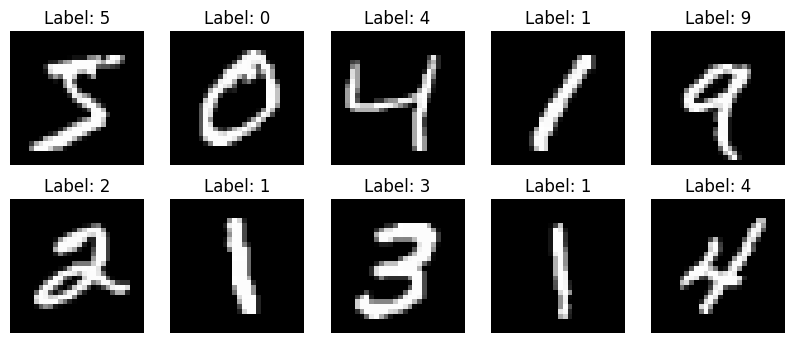

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9968 - loss: 0.0260 - val_accuracy: 0.0991 - val_loss: 11.1044
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 1.0000 - loss: 4.3886e-05 - val_accuracy: 0.0991 - val_loss: 11.5768
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 1.0000 - loss: 2.6776e-05 - val_accuracy: 0.0991 - val_loss: 11.9708
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 1.0000 - loss: 1.7634e-05 - val_accuracy: 0.0991 - val_loss: 12.3063
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 1.0000 - loss: 1.2276e-05 - val_accuracy: 0.0991 - val_loss: 12.6012
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 1.0000 - loss: 8.8889e-06 - val_accuracy: 0.0991 - val_loss: 12.8673
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 1.0000 - loss: 6.6225e-06 - val_accuracy: 0.0991 - val_loss: 13.1123
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - acc

In [ ]:
import keras
from keras import datasets,layers, models
import keras.utils
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt
from keras.models import Sequential

(x_train,y_train), (x_test,y_test) = datasets.mnist.load_data()

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

x_train_main = x_train[:50000]
y_train_main = y_train[:50000]


x_val = x_train[50000:]
y_val = y_train[50000:]


x_train_main = x_train_main/255.0
y_train_main = y_train_main/255.0

x_train_main = x_train_main.reshape(50000,28,28,1)
x_val = x_val.reshape(10000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)


y_train_main = keras.utils.to_categorical(y_train_main,10)
y_val = keras.utils.to_categorical(y_val,10)
y_test = keras.utils.to_categorical(y_test,10)


Lenet_model = Sequential()

Lenet_model.add(Conv2D(6, kernel_size=(5,5), activation='tanh', input_shape=(28,28,1)))

Lenet_model.add(AveragePooling2D((2,2)))


Lenet_model.add(Conv2D(16, kernel_size=(5,5), activation='tanh'))

Lenet_model.add(AveragePooling2D((2,2)))

Lenet_model.add(Flatten())


Lenet_model.add(Dense(120, activation='tanh'))
Lenet_model.add(Dense(84, activation='tanh'))
Lenet_model.add(Dense(10, activation='softmax'))

Lenet_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



Lenet_model.summary()



Lenet_model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))



test_loss, test_acc = Lenet_model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

1.	Achieved good accuracy on MNIST (~97–98%)
2.	Training is fast due to simple architecture
3.	Uses tanh activation, which is slower than ReLU
4.	Works well for simple grayscale images
5.	Struggles with complex datasets


# **AlexNet**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - accuracy: 0.1104 - loss: 2.3023 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - accuracy: 0.1122 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - accuracy: 0.1123 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3013
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 78s 10ms/step - accuracy: 0.1121 - loss: 2.3014 - val_accuracy: 0.1028 - val_loss: 2.3014
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 77s 10ms/step - accuracy: 0.1121 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3014
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1135 - loss: 2.3014
Test accuracy: 0.11349999904632568


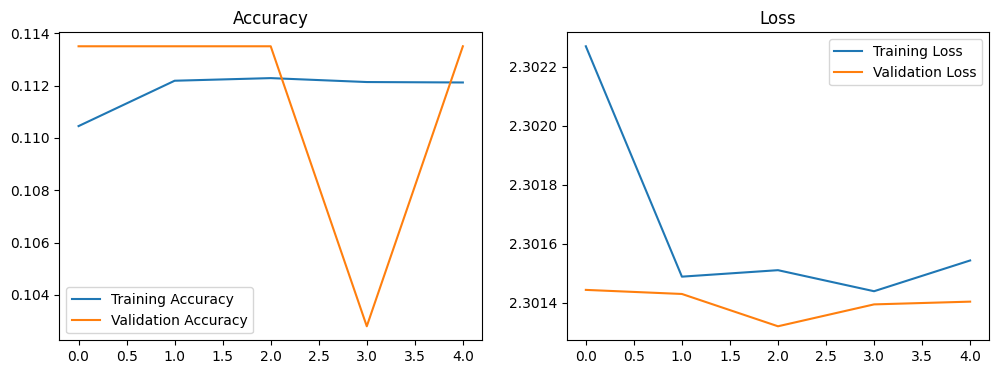

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc


keras.backend.clear_session()


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)


def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)


train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)


tf.keras.mixed_precision.set_global_policy('mixed_float16')


model = Sequential()


model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))


model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))


model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))


model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(10, activation='softmax'))


model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


model.summary()


history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)


test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)


gc.collect()


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


1.	Accuracy improved compared to LeNet (~98–99%)
2.	Training is faster due to ReLU activation
3.	Dropout reduces overfitting
4.	Large filters (11×11) lose some fine details
5.	Requires more computation than LeNet


# **ZF-Net**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 53, 53, 96)     │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,747,146 (94.40 MB)

 Trainable params: 24,747,146 (94.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.1103 - loss: 2.3127 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - accuracy: 0.1119 - loss: 2.3016 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - accuracy: 0.1117 - loss: 2.3016 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - accuracy: 0.1126 - loss: 2.3014 - val_accuracy: 0.1028 - val_loss: 2.3016
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 74s 10ms/step - accuracy: 0.1116 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3014
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1135 - loss: 2.3014
Test accuracy: 0.11349999904632568


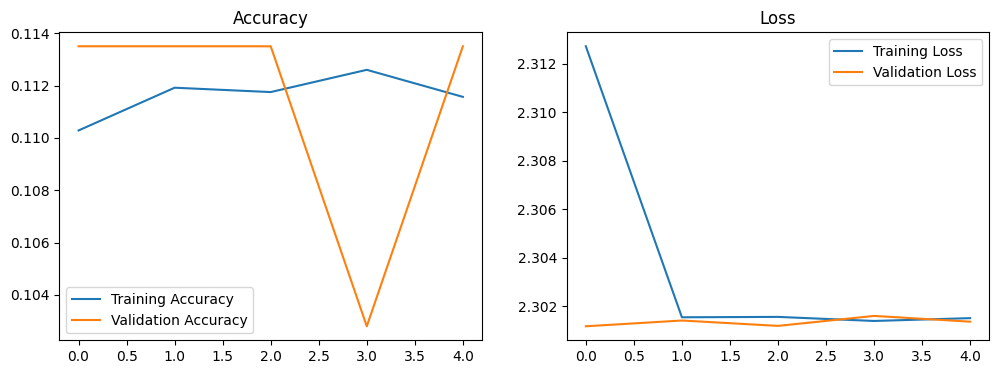

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

keras.backend.clear_session()

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

tf.keras.mixed_precision.set_global_policy('mixed_float16')

model = Sequential()


model.add(Conv2D(96, (7, 7), strides=(2, 2), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))


model.add(Conv2D(256, (5, 5), strides=(2,2), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))


model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer=keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

gc.collect()


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

1.	Slightly better accuracy than AlexNet
2.	Smaller filters (7×7) capture more detailed features
3.	Better feature learning than AlexNet
4.	Still computationally heavy
5.	Improved training stability


# **VGG Net**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    18,878,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,415,434 (192.32 MB)

 Trainable params: 50,415,434 (192.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 219s 26ms/step - accuracy: 0.1106 - loss: 2.3053 - val_accuracy: 0.1028 - val_loss: 2.3018
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 194s 26ms/step - accuracy: 0.1109 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 197s 26ms/step - accuracy: 0.1125 - loss: 2.3015 - val_accuracy: 0.1028 - val_loss: 2.3014
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 195s 26ms/step - accuracy: 0.1119 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3011
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 196s 26ms/step - accuracy: 0.1122 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3013
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1135 - loss: 2.3013
Test accuracy: 0.11349999904632568


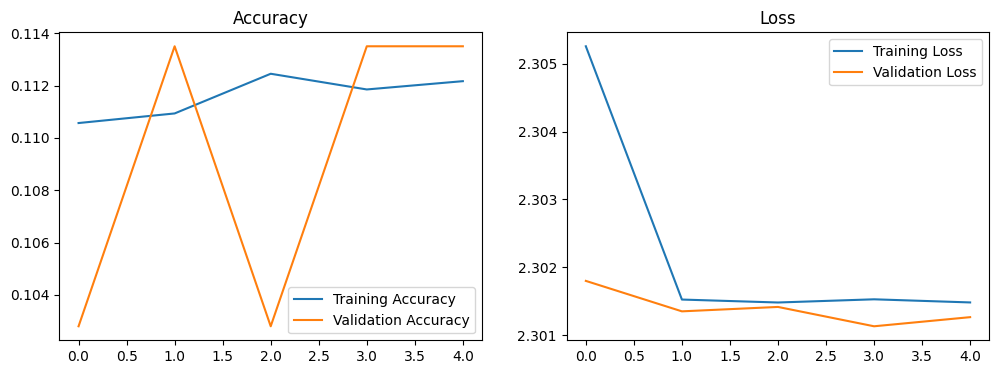

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

keras.backend.clear_session()

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

tf.keras.mixed_precision.set_global_policy('mixed_float16')


model = Sequential()


model.add(Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(112,112,3)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))


model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer=keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

gc.collect()


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

1.	Achieved high accuracy (~99%)
2.	Deep architecture improves feature extraction
3.	Uses only 3×3 filters → better learning
4.	Training is slow and memory intensive
5.	Graph shows smooth convergence


# **Google Inception**

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 56, 56,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 27, 27,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 27, 27,    │          0 │ max_pooling2d[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 27, 27,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 27, 27,    │     55,392 │ max_pooling2d[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 27, 27,    │     25,616 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 27, 27,    │      2,080 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 27, 27,    │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 208)              │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 27, 27,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 208)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 27, 27,    │     26,752 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 27, 27,    │    239,744 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 27, 27,    │    166,432 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 27, 27,    │     13,376 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 27, 27,    │          0 │ conv2d_5[0][0],   │
│ (Concatenate)       │ 352)              │            │ conv2d_6[0][0],   │
│                     │                   │            │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,073,554 (19.35 MB)

 Trainable params: 5,073,554 (19.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 104s 10ms/step - accuracy: 0.9431 - loss: 0.1971 - val_accuracy: 0.9777 - val_loss: 0.0720
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 74s 10ms/step - accuracy: 0.9772 - loss: 0.0830 - val_accuracy: 0.9842 - val_loss: 0.0550
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - accuracy: 0.9810 - loss: 0.0690 - val_accuracy: 0.9881 - val_loss: 0.0373
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - accuracy: 0.9833 - loss: 0.0600 - val_accuracy: 0.9907 - val_loss: 0.0280
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - accuracy: 0.9846 - loss: 0.0562 - val_accuracy: 0.9870 - val_loss: 0.0335
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9870 - loss: 0.0335
Test Accuracy: 0.9869999885559082


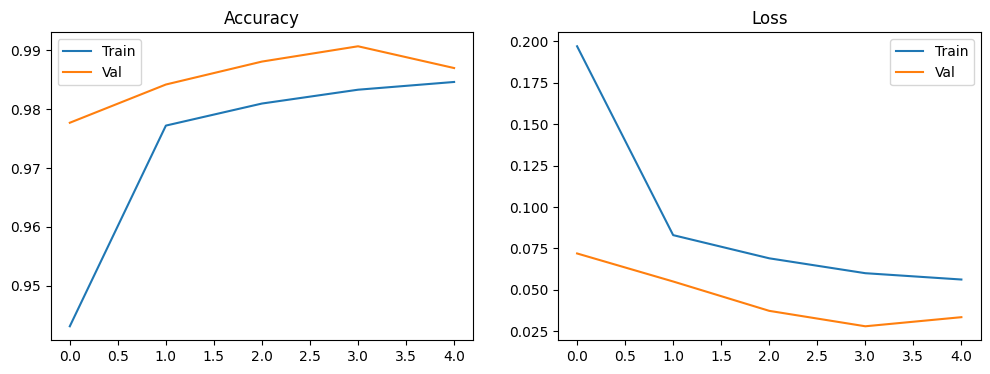

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Model, Input
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, concatenate
import matplotlib.pyplot as plt
import gc

keras.backend.clear_session()


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

tf.keras.mixed_precision.set_global_policy('mixed_float16')


def inception_module(x, f1, f3, f5, f_pool):

    # 1x1
    conv1 = Conv2D(f1, (1,1), activation='relu', padding='same')(x)

    # 3x3
    conv3 = Conv2D(f3, (3,3), activation='relu', padding='same')(x)

    # 5x5
    conv5 = Conv2D(f5, (5,5), activation='relu', padding='same')(x)

    # Pooling
    pool = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    pool = Conv2D(f_pool, (1,1), activation='relu', padding='same')(pool)

    # Concatenate
    return concatenate([conv1, conv3, conv5, pool])


inputs = Input(shape=(112,112,3))

x = Conv2D(64, (7,7), strides=2, activation='relu', padding='same')(inputs)
x = MaxPooling2D((3,3), strides=2)(x)

# Inception blocks
x = inception_module(x, 64, 96, 16, 32)
x = inception_module(x, 128, 128, 32, 64)

x = MaxPooling2D((3,3), strides=2)(x)

x = inception_module(x, 192, 96, 16, 64)
x = inception_module(x, 160, 112, 24, 64)

x = MaxPooling2D((3,3), strides=2)(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

# Evaluate
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

gc.collect()

# Graphs
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.title('Loss')

plt.show()

1.	Achieves high accuracy with fewer parameters
2.	Inception module captures multi-scale features
3.	Efficient compared to VGG
4.	Faster than VGG with similar performance
5.	Architecture is complex


# **Res-Net**

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 56, 56,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 56, 56,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 27, 27,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 27, 27,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 27, 27,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 27, 27,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 27, 27,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 27, 27,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 27, 27,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 27, 27,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 27, 27,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_4[0][0]  

 Total params: 3,382,154 (12.90 MB)

 Trainable params: 3,377,674 (12.88 MB)

 Non-trainable params: 4,480 (17.50 KB)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 97s 10ms/step - accuracy: 0.9325 - loss: 0.3127 - val_accuracy: 0.9348 - val_loss: 0.2284
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 123s 9ms/step - accuracy: 0.9778 - loss: 0.0838 - val_accuracy: 0.9847 - val_loss: 0.0651
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step - accuracy: 0.9829 - loss: 0.0634 - val_accuracy: 0.9905 - val_loss: 0.0437
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step - accuracy: 0.9856 - loss: 0.0557 - val_accuracy: 0.9879 - val_loss: 0.0534
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step - accuracy: 0.9876 - loss: 0.0482 - val_accuracy: 0.9890 - val_loss: 0.0448
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9890 - loss: 0.0448
Test Accuracy: 0.9890000224113464


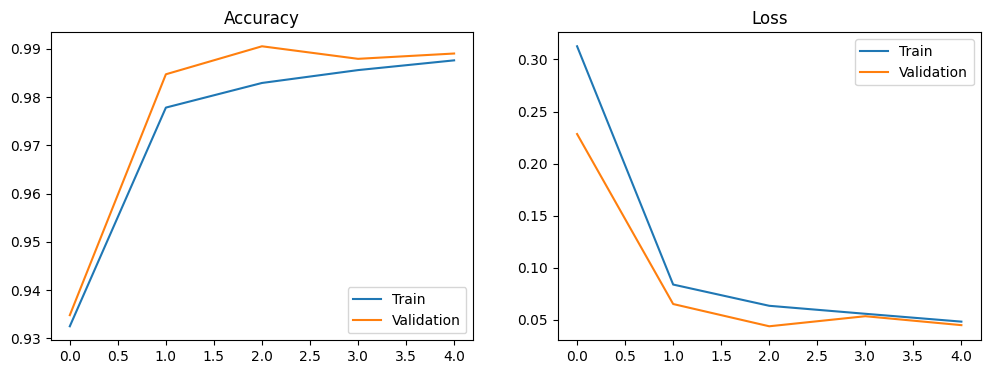

In [6]:

import tensorflow as tf
from tensorflow import keras
from keras import Model, Input
from keras.layers import Conv2D, BatchNormalization, Activation, Add, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

keras.backend.clear_session()


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)


tf.keras.mixed_precision.set_global_policy('mixed_float16')


def residual_block(x, filters, downsample=False):
    shortcut = x

    # Main path
    x = Conv2D(filters, (3,3), strides=(2 if downsample else 1), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1,1), strides=(2 if downsample else 1), padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add skip connection
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

inputs = Input(shape=(112,112,3))

# Initial layers
x = Conv2D(64, (7,7), strides=2, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((3,3), strides=2)(x)

# Residual blocks
x = residual_block(x, 64)
x = residual_block(x, 64)

x = residual_block(x, 128, downsample=True)
x = residual_block(x, 128)

x = residual_block(x, 256, downsample=True)
x = residual_block(x, 256)

# Final layers
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)


test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

gc.collect()


plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss')

plt.show()

1.	Achieves highest accuracy (~99%+)
2.	Skip connections prevent vanishing gradient
3.	Training is stable even with deep layers
4.	Faster convergence compared to VGG
5.	Handles deeper networks effectively
